---
# Documentation: https://wowchemy.com/docs/managing-content/

title: "Geoekonomi (2): seberapa terpapar Indonesia?"
subtitle: ""
summary: ""
authors: [admin]
tags: [perdagangan, industri, AS, Tiongkok, geoeconomics]
categories: [Perdagangan, Industri]
date: 2026-06-29T10:00:00+07:00
lastmod: 2026-06-29T10:00:00+07:00
featured: false
draft: false

# Featured image
# To use, add an image named `featured.jpg/png` to your page's folder.
# Focal points: Smart, Center, TopLeft, Top, TopRight, Left, Right, BottomLeft, Bottom, BottomRight.
image:
  caption: ""
  focal_point: ""
  preview_only: false

# Projects (optional).
#   Associate this post with one or more of your projects.
#   Simply enter your project's folder or file name without extension.
#   E.g. `projects = ["internal-project"]` references `content/project/deep-learning/index.md`.
#   Otherwise, set `projects = []`.
projects: []
---

Post ini lanjutan dari [post sebelumnya](../geoeconomics) di mana saya mencoba ngeliat posisi Indonesia di tengah dunia yang makin geoekonomis. Kalau di post itu kita ngobrol konsepnya dan ngeplot indeks GPR-nya Caldara & Iacoviello buat Indonesia, kali ini kita bikin sedikit lebih konkret: di mana _sih_ sebenernya posisi Indonesia kalau benar-benar diukur?

Ada dua hal yang mau saya tunjukin. **Pertama**, GPR tertimbang perdagangan — seberapa besar Indonesia berdagang dengan negara-negara yang lagi tinggi risiko geopolitiknya. **Kedua**, GeoV dan GeoC — di mana kita berdiri kalau yang dipertimbangkan adalah _jarak ideal-point_, yaitu seberapa mirip pola voting kita dengan mitra dagang di Majelis Umum PBB.

## 1. GPR tertimbang mitra dagang

Idenya sederhana. GPR global naik-turun buat semua orang, tapi yang relevan buat kita adalah risiko geopolitik dari negara-negara yang justru jadi mitra dagang Indonesia. Jadi kita timbang GPR spesifik tiap negara[^1] dengan pangsa perdagangan Indonesia ke negara itu, lalu dijumlahkan. Makin tinggi angkanya, makin banyak perdagangan kita nyangkut di negara yang lagi panas-panasnya secara geopolitik.

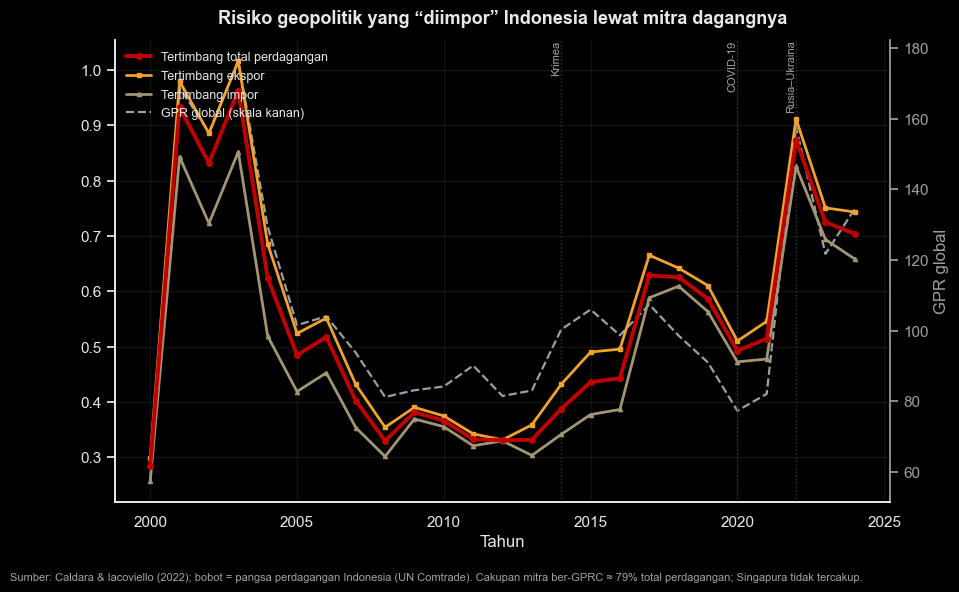

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import fig_den as den

# --- DEN house style + dark mode (latar hitam), sama seperti post sebelumnya ---
den.style()
BG, FG, GRID = "#000000", "#E8E8E8", "#3A3A3A"
plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": BG, "savefig.facecolor": BG,
    "text.color": FG, "axes.labelcolor": FG, "axes.titlecolor": FG,
    "xtick.color": FG, "ytick.color": FG, "axes.edgecolor": FG,
    "grid.color": GRID,
})
RED, GOLD, TAN = den.RED, den.GOLD, den.TAN
GLOBAL = "#9AA0A6"

# --- Data: GPR tertimbang mitra dagang Indonesia (Caldara & Iacoviello 2022 x UN Comtrade) ---
gpr = pd.read_csv("gpr_partner_weighted.csv")

fig, ax = den.subplots(figsize=(10, 6))
ax2 = ax.twinx()
ax2.grid(False)
ax2.set_facecolor("none")

# GPR global di sumbu kanan (di belakang)
l0, = ax2.plot(gpr.year, gpr.gpr_global, color=GLOBAL, lw=1.6, ls="--",
               label="GPR global (skala kanan)", zorder=1)
l1, = ax.plot(gpr.year, gpr.gpr_total_wt, color=RED, lw=2.8, marker="o", ms=4,
              label="Tertimbang total perdagangan", zorder=4)
l2, = ax.plot(gpr.year, gpr.gpr_export_wt, color=GOLD, lw=2.0, marker="s", ms=3,
              label="Tertimbang ekspor", zorder=3)
l3, = ax.plot(gpr.year, gpr.gpr_import_wt, color=TAN, lw=2.0, marker="^", ms=3,
              label="Tertimbang impor", zorder=3)

ymax = ax.get_ylim()[1]
for yr, lab in [(2014, "Krimea"), (2020, "COVID-19"), (2022, "Rusia–Ukraina")]:
    ax.axvline(yr, color=GRID, ls=":", lw=1, alpha=0.9, zorder=0)
    ax.text(yr, ymax, lab, rotation=90, va="top", ha="right",
            fontsize=8, color=FG, alpha=0.7)

ax.set_ylabel("GPR mitra, tertimbang perdagangan")
ax2.set_ylabel("GPR global", color=GLOBAL)
ax2.tick_params(axis="y", colors=GLOBAL)
ax2.spines["right"].set_visible(True)
ax2.spines["right"].set_color(GLOBAL)
ax.set_zorder(ax2.get_zorder() + 1)
ax.patch.set_visible(False)
ax.margins(x=0.01)

den.label(ax, title="Risiko geopolitik yang “diimpor” Indonesia lewat mitra dagangnya",
          xlabel="Tahun")
ax.legend([l1, l2, l3, l0], [h.get_label() for h in (l1, l2, l3, l0)],
          loc="upper left", frameon=False, fontsize=9)
fig.text(0.02, -0.02,
         "Sumber: Caldara & Iacoviello (2022); bobot = pangsa perdagangan Indonesia (UN Comtrade). "
         "Cakupan mitra ber-GPRC ≈ 79% total perdagangan; Singapura tidak tercakup.",
         fontsize=8, color=FG, alpha=0.7)
plt.show()

Grafik di atas: sumbu horizontal tahun (2000–2024), sumbu kiri GPR mitra tertimbang perdagangan Indonesia (versi total, ekspor, dan impor), sumbu kanan GPR global sebagai pembanding. Garis titik-titik menandai episode krisis.

Tiga hal menarik. **Satu**, risiko geopolitik yang "diimpor" Indonesia lewat mitra dagangnya kira-kira **berlipat dua** dari titik terendahnya sekitar 2012–13 (~0,33) ke puncak 2022 (~0,87), dan masih tinggi di 2024 (~0,70). **Dua**, deret tertimbang Indonesia nggak cuma ngikutin GPR global — di 2017–2019 dia malah _menyimpang ke atas_ relatif tren global. Artinya, kenaikan paparan ini bukan semata karena dunia lagi ribut, tapi karena **komposisi mitra dagang kita bergeser** ke negara yang risikonya lebih tinggi (terutama Tiongkok, dan untuk komoditas tertentu, Rusia). **Tiga**, deret tertimbang ekspor konsisten berada di atas impor — sisi ekspor kita lebih terpapar ke mitra berisiko.

## 2. GeoV dan GeoC: jarak ideal-point

GPR ngukur "panas"-nya mitra. Tapi ada cara lain ngeliat posisi kita: seberapa _jauh_ mitra kita secara politik. Aiyar & Ohnsorge[^2] memakai jarak _ideal-point_ dari pola voting di PBB[^3] buat bikin dua indeks. **GeoV** (_vulnerability_) adalah rata-rata tertimbang jarak ideal-point mitra kita — makin tinggi, makin terpapar ke mitra yang jauh secara politik; inilah "posisi" Indonesia dalam ruang ideal-point. **GeoC** (_connectedness_) adalah simpangan bakunya — makin tinggi, makin luas rentang ideologi mitra kita, ciri khas negara "penghubung" yang dagang dengan kedua kubu.

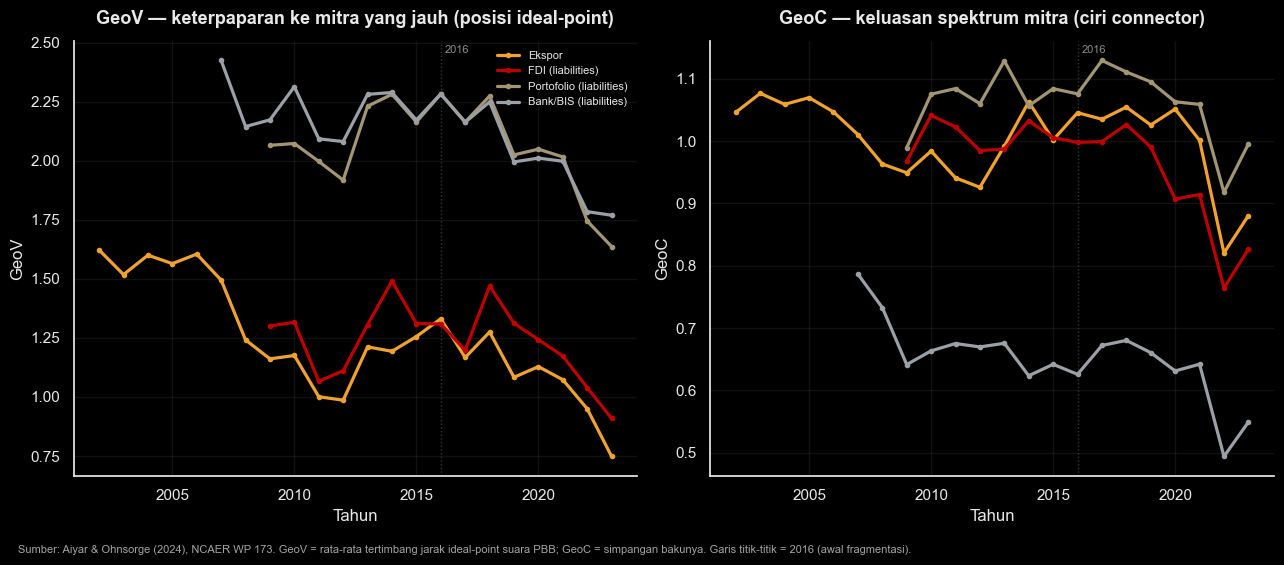

In [2]:
# --- Data: GeoV & GeoC Indonesia per jenis transaksi (Aiyar & Ohnsorge 2024) ---
geo = pd.read_csv("indonesia_geo_vc.csv").sort_values("year")

TXN = {"exports":      ("Ekspor", GOLD),
       "fdi_in_stock": ("FDI (liabilities)", RED),
       "pfi_in_stock": ("Portofolio (liabilities)", TAN),
       "banks":        ("Bank/BIS (liabilities)", GLOBAL)}

fig, (axV, axC) = den.subplots(1, 2, figsize=(13, 5.5))
for ax in (axV, axC):
    ax.set_facecolor(BG)
    ax.axvline(2016, color=GRID, ls=":", lw=1, alpha=0.9)

for t, (lab, col) in TXN.items():
    sV = geo.dropna(subset=[f"GeoV_{t}"])
    axV.plot(sV.year, sV[f"GeoV_{t}"], marker="o", ms=3, lw=2.3, color=col, label=lab)
    sC = geo.dropna(subset=[f"GeoC_{t}"])
    axC.plot(sC.year, sC[f"GeoC_{t}"], marker="o", ms=3, lw=2.3, color=col, label=lab)

# tandai 2016 di pojok atas tiap panel (setelah data diplot agar posisinya pas)
for ax in (axV, axC):
    ax.annotate("2016", xy=(2016, 1), xycoords=("data", "axes fraction"),
                xytext=(3, -3), textcoords="offset points",
                va="top", ha="left", fontsize=8, color=FG, alpha=0.6)

den.label(axV, title="GeoV — keterpaparan ke mitra yang jauh (posisi ideal-point)",
          xlabel="Tahun", ylabel="GeoV")
den.label(axC, title="GeoC — keluasan spektrum mitra (ciri connector)",
          xlabel="Tahun", ylabel="GeoC")
axV.legend(frameon=False, fontsize=8, loc="upper right")

fig.text(0.02, -0.02,
         "Sumber: Aiyar & Ohnsorge (2024), NCAER WP 173. GeoV = rata-rata tertimbang jarak ideal-point suara PBB; "
         "GeoC = simpangan bakunya. Garis titik-titik = 2016 (awal fragmentasi).",
         fontsize=8, color=FG, alpha=0.7)
fig.tight_layout()
plt.show()

Dua panel di atas: sumbu horizontal tahun, sumbu vertikal nilai indeks, dipecah per jenis transaksi (ekspor, FDI, portofolio, dan pinjaman bank). Garis titik-titik = 2016, kira-kira saat fragmentasi mulai kelihatan.

Hasilnya bikin agak mikir. GeoV ekspor Indonesia justru **turun**, dari 1,62 (2002) ke 1,33 (2016) lalu 0,75 (2023). Sekilas kayak kabar baik: ekspor kita makin ke mitra yang secara politik lebih _dekat_ dengan Jakarta. Tapi lihat GeoC-nya — **ikut turun** juga (~1,05 ke ~0,88). Rentang ideologi mitra dagang kita **menyempit**. Jadi turunnya GeoV bukan tanda diversifikasi yang sehat, melainkan **konsentrasi** ke segelintir mitra besar (lagi-lagi, Tiongkok).

Gabungkan ketiganya dan polanya konsisten: GPR tertimbang **naik**, GeoV **turun**, GeoC **turun**. Indonesia makin mengonsentrasikan dagangnya ke mitra yang lebih selaras secara politik _tapi_ membawa risiko geopolitik intrinsik yang lebih tinggi, sambil mengikis keluasan portofolio yang justru jadi modal kita sebagai negara penghubung.

Ini yang menurut saya perlu kita pantau terus. Di dunia yang makin multipolar, perdagangan bukan lagi soal efisiensi ekonomi semata — siapa mitra dagang kita sekarang punya bobot strategis. Tradisi politik bebas-aktif sebenarnya bikin Indonesia kandidat alami sebagai _connector_, tapi peran itu cuma bernilai kalau kita jaga keluasan mitra dan nggak keseret masuk orbit satu blok saja. Datanya, sejauh ini, justru menunjukkan arah yang sebaliknya. Apa boleh buat — seperti saya bilang di post sebelumnya, mempelajari ini jadi tanggung jawab tersendiri.

[^1]: Caldara, Dario, and Matteo Iacoviello. 2022. “Measuring Geopolitical Risk.” _American Economic Review_ 112 (4): 1194–1225. Versi negara-spesifik (GPRC) mencakup 44 negara; karena Singapura tidak termasuk, bobot dinormalkan ulang pada mitra tercakup (~79% total perdagangan).

[^2]: Aiyar, Shekhar, and Franziska Ohnsorge. 2024. “Geoeconomic Fragmentation and ‘Connector’ Countries.” MPRA Working Paper 121726 / NCAER Working Paper 173.

[^3]: Bailey, Michael A., Anton Strezhnev, and Erik Voeten. 2017. “Estimating Dynamic State Preferences from United Nations Voting Data.” _Journal of Conflict Resolution_ 61 (2): 430–456.